# Tutorial: 3D Image Classification  

> SynapseMNIST3D dataset demo


In [ ]:
#| default_exp tutorial_classification_3D

### Setup imports

In [ ]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from bioMONAI.core import *
from bioMONAI.core import Path
#from bioMONAI.data import get_image_files, get_target, RandomSplitter
from bioMONAI.losses import *
from bioMONAI.metrics import *
from bioMONAI.datasets import download_medmnist
from bioMONAI.visualize import show_images_grid, mosaic_image_3d


#from monai.utils import set_determinism
#from monai.transforms import ScaleIntensity

#set_determinism(0)

In [ ]:
device = get_device()
print(device)

cpu


CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343995622/work/c10/cuda/CUDAFunctions.cpp:109.)


### Download and store the dataset

In [ ]:
data_flag = 'synapsemnist3d'
data_path = Path('../_data/medmnist_data/')

info = download_medmnist(data_flag, data_path, download_only=True)

data_path = data_path/'synapsemnist3d'
train_path = data_path/'train'
val_path = data_path/'val'
test_path = data_path/'test'

Dataset 'synapsemnist3d' is already downloaded and available in '../_data/medmnist_data/synapsemnist3d'.


### Create Dataloader

In [ ]:
batch_size = 8

data = BioDataLoaders.class_from_folder(
    data_path,
    train='train',
    valid='val',
    vocab=info['label'],
    item_tfms=[ScaleIntensity(), RandRot90(prob=0.5), Resize(32)],
    batch_tfms=None,
    img_cls=BioImageStack,
    bs=batch_size,
    show_summary=True,
    )

# print length of training and validation datasets
print('train images:', len(data.train_ds.items), '\nvalidation images:', len(data.valid_ds.items))

Setting-up type transforms pipelines
Found 1407 items
2 datasets of sizes 1230,177
Setting up Pipeline: BioImageBase.create -> Tensor2BioImage -- {}
Setting up Pipeline: parent_label -> Categorize -- {'vocab': ['0', '1'], 'sort': True, 'add_na': False}

Building one sample
  Pipeline: BioImageBase.create -> Tensor2BioImage -- {}
    starting from
      ../_data/medmnist_data/synapsemnist3d/train/1/train_865.tiff
    applying BioImageBase.create gives
      BioImageStack of size 1x28x28x28
    applying Tensor2BioImage -- {} gives
      BioImageStack of size 1x28x28x28
  Pipeline: parent_label -> Categorize -- {'vocab': ['0', '1'], 'sort': True, 'add_na': False}
    starting from
      ../_data/medmnist_data/synapsemnist3d/train/1/train_865.tiff
    applying parent_label gives
      1
    applying Categorize -- {'vocab': ['0', '1'], 'sort': True, 'add_na': False} gives
      TensorCategory(1)

Final sample: (BioImageStack([[[[0.8039, 0.8706, 0.4980,  ..., 0.4353, 0.1451, 0.2157],
       

In [ ]:
#im, label = data.train_ds[0]
#print(type(im), im.shape, label, label.shape)

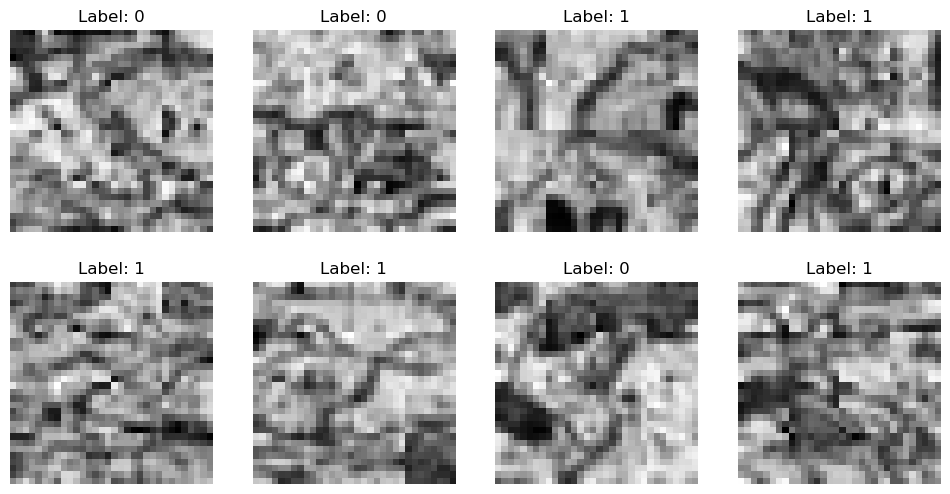

In [ ]:
data.show_batch()

### Load and train a 3D model

In [ ]:
from monai.networks.nets import DenseNet121, HighResNet
from fastai.vision.all import BalancedAccuracy, CrossEntropyLossFlat
# from torch.nn import CrossEntropyLoss

#model = HighResNet
model = DenseNet121(spatial_dims=3, in_channels=1, out_channels=1)

loss = CrossEntropyLossFlat()
metric = BalancedAccuracy

trainer = fastTrainer(data, model, loss_fn=loss, metrics=metric, show_summary=True)

DenseNet121 (Input shape: 8 x 1 x 32 x 32 x 32)
Layer (type)         Output Shape         Param #    Trainable 
                     8 x 64 x 16 x 16 x  
Conv3d                                    21952      True      
BatchNorm3d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     8 x 64 x 8 x 8 x 8  
MaxPool3d                                                      
BatchNorm3d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     8 x 128 x 8 x 8 x 8 
Conv3d                                    8192       True      
BatchNorm3d                               256        True      
ReLU                                                           
________________________________

In [ ]:
trainer.fit(1)

In [ ]:
#trainer.show_results(cmap='gray')

In [ ]:
# trainer.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!